## Nationality Classification via Deep Learning

**Goal:** Build a deep-learning model that predicts a person's nationality using only their name.

### Core Points
- **Input Strategy:** Character-level tokenization to learn language-specific patterns and sub-word structures.
- **Model Search:** Bayesian optimization (Keras Tuner) to determine the best network configuration (GRU layers, dense units, dropout).
- **Training Setup:** Adaptive learning-rate scheduling (ReduceLROnPlateau) to maintain progress as training plateaus.


## Data Loading

In [1]:
import pandas as pd 
df = pd.read_csv('/kaggle/input/nationality-csv/nationality.csv')

## word level tokenization

In [2]:
import tensorflow as tf

tokenizer = tf.keras.preprocessing.text.Tokenizer(char_level=True)
tokenizer.fit_on_texts(df['nama'])

all_tokenizer_words = tokenizer.word_index

sequence = tokenizer.texts_to_sequences(df['nama'])
X = tf.keras.utils.pad_sequences(sequence, maxlen=43, padding='pre')

2025-11-25 04:15:56.417291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764044156.594906      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764044156.648519      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## splitting data into train and test

In [3]:
from sklearn.model_selection import train_test_split
y = df['country']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## Finding the best model architecture using Keras Tuner 

In [4]:
def build_model(hp):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Embedding(input_dim=42, output_dim= 512, input_length = 43))

    gru_layers = hp.Choice('gru_layers',[1,2,3,4])

    for i in range(gru_layers):
        model.add(tf.keras.layers.GRU(
            units=hp.Choice(f'gru_unit{i}', [32, 64, 128]),
            return_sequences= (i < gru_layers -1)
        ))

        model.add(tf.keras.layers.LayerNormalization())

    for i in range(hp.Choice('dense_layers', [1,2,3])):
        model.add(tf.keras.layers.Dense(
            units=hp.Int(f'dense_units{i}', 32,128, step=32),
            activation='relu'
        ))
        model.add(tf.keras.layers.Dropout(hp.Float('dropouts', 0.0, 0.5, step=0.1)))
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.Dense(18, activation='softmax'))

    model.compile(
        loss=tf.keras.losses.sparse_categorical_crossentropy,
        optimizer='adam',
        metrics=['accuracy']
    )

    return model       

In [5]:
import keras_tuner
tuner = keras_tuner.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=30,
    directory='my_model',
    project_name='BayesianOptimization'
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1764044170.482210      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
tuner.search(X_train,y_train, batch_size = 256, epochs= 20, validation_data=(X_test, y_test),
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss',
                    patience=3,
                    restore_best_weights=True
                )
            ])

Trial 30 Complete [00h 03m 52s]
val_loss: 0.2638140320777893

Best val_loss So Far: 0.16281795501708984
Total elapsed time: 01h 26m 54s


In [7]:
# Building Model with best parameters
best_hp = tuner.get_best_hyperparameters()[0]
model = tuner.hypermodel.build(best_hp)

In [8]:
for hp in best_hp.space:
    print(f'--{hp.name}:{best_hp.get(hp.name)}')

--gru_layers:3
--gru_unit0:128
--dense_layers:1
--dense_units0:64
--dropouts:0.1
--gru_unit1:64
--gru_unit2:64
--gru_unit3:64
--dense_units1:32


In [9]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

In [10]:
# Training process
history = model.fit(X_train, y_train, epochs=80, batch_size = 1024, validation_data=(X_test, y_test),
                   callbacks=[lr_scheduler])

Epoch 1/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.4478 - loss: 1.8334 - val_accuracy: 0.7383 - val_loss: 1.0004 - learning_rate: 0.0010
Epoch 2/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7576 - loss: 0.7735 - val_accuracy: 0.8041 - val_loss: 0.6310 - learning_rate: 0.0010
Epoch 3/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8180 - loss: 0.5731 - val_accuracy: 0.8368 - val_loss: 0.5021 - learning_rate: 0.0010
Epoch 4/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8525 - loss: 0.4613 - val_accuracy: 0.8550 - val_loss: 0.4357 - learning_rate: 0.0010
Epoch 5/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8770 - loss: 0.3813 - val_accuracy: 0.8760 - val_loss: 0.3848 - learning_rate: 0.0010
Epoch 6/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8941 - loss: 0.3267 - val_accuracy: 0.8997 - val_loss: 0.3078 - learning_rate: 0.0010
Epoch 7/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9103 - loss: 0

## Evaluation

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print('Val_loss', loss)
print('Val_Aaccuracy', accuracy)

877/877 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9629 - loss: 0.1707
Val_loss 0.16610705852508545
Val_Aaccuracy 0.9629418253898621


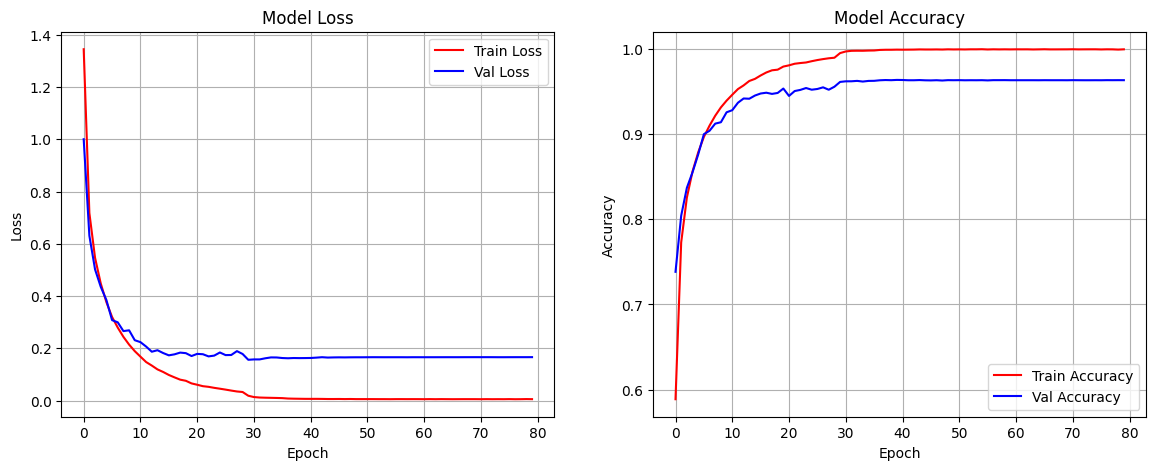

In [12]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss', color='red')
ax1.plot(history.history['val_loss'], label='Val Loss', color='blue')
ax1.set_title('Model Loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Train Accuracy', color='red')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='blue')
ax2.set_title('Model Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.show()

## Final Evaluation & Performance

**Overall Result:** The model reached excellent validation performance with consistently low validation loss.

### Why It Worked Well

- **Sufficient Depth:** Hyperparameter tuning revealed that increasing architectural depth was necessary to capture the complex sequential patterns present in names.
- **Solid Regularization:** Dropout and batch normalization reduced overfitting risk and improved generalization despite the model’s size.
- **Refined Optimization:** A progressively reduced learning rate enabled rapid early learning followed by precise late-stage adjustments, driving the model toward strong final performance.
